<a href="https://colab.research.google.com/github/TAUforPython/BaseControlTheory/blob/main/Lyapunov_stability_theory.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Пример из теория устойчивости по Ляпунову

## Определения

### Устойчивость по Ляпунову
Точка равновесия $x^*$ называется **устойчивой по Ляпунову**, если для любого $\epsilon > 0$ существует $\delta > 0$ такое, что если начальное состояние системы находится на расстоянии менее $\delta$ от $x^*$, то траектория системы всегда остается на расстоянии менее $\epsilon$ от $x^*$.

### Асимптотическая устойчивость
Точка равновесия **асимптотически устойчива**, если:
1. Она устойчива по Ляпунову.
2. Существует такое $\delta > 0$, что если начальное состояние находится на расстоянии менее $\delta$ от $x^*$, то траектория стремится к $x^*$ при $t \to \infty$.

### Экспоненциальная устойчивость
Более сильная форма устойчивости, при которой траектория стремится к точке равновесия экспоненциально быстро.

## Линеаризация и анализ устойчивости

Для нелинейной системы $\dot{x} = f(x)$ с точкой равновесия $x^*$ линеаризуем систему вокруг этой точки:

$$\dot{\xi} = J(x^*) \xi$$

где:
- $J(x^*)$ — **якобиан** векторного поля $f$ в точке $x^*$,
- $\xi = x - x^*$ — малое отклонение.

### Критерий устойчивости
- **Асимптотическая устойчивость** — если **все** собственные значения якобиана имеют **отрицательные** вещественные части.
- **Неустойчивость** — если хотя бы одно собственное значение имеет **положительную** вещественную часть.
- **Сомнительный случай** — если собственные значения имеют **нулевые** вещественные части (требуется более глубокий анализ: метод функций Ляпунова или исследование нелинейных членов).

---

## Применительно к вашей системе

### Якобиан в точке $(0,0)$
$$J(0,0) = \begin{pmatrix} 1 & 1 \\ 0 & -3 \end{pmatrix}$$

### Собственные значения
$$\lambda_1 = 1, \quad \lambda_2 = -3$$

### Вывод об устойчивости
Поскольку одно из собственных значений ($\lambda_1 = 1$) **положительно**, точка равновесия $(0,0)$ **неустойчива**.

Якобиан системы:
Matrix([[exp(x1), cos(x2)], [2*x2, 2*x1 - 3]])

Якобиан в точке (0,0):
Matrix([[1, 1], [0, -3]])

Собственные значения якобиана в точке (0,0):
[ 1. -3.]

Точка (0,0) является неустойчивой.


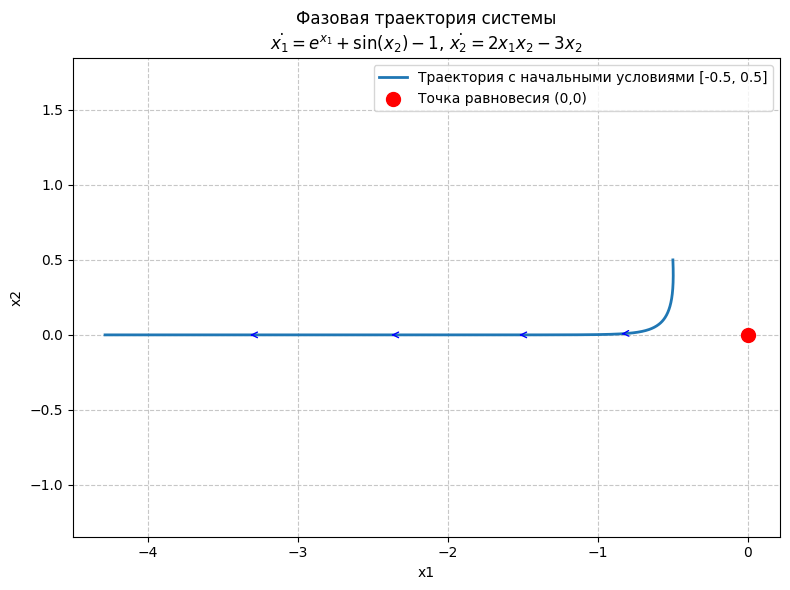

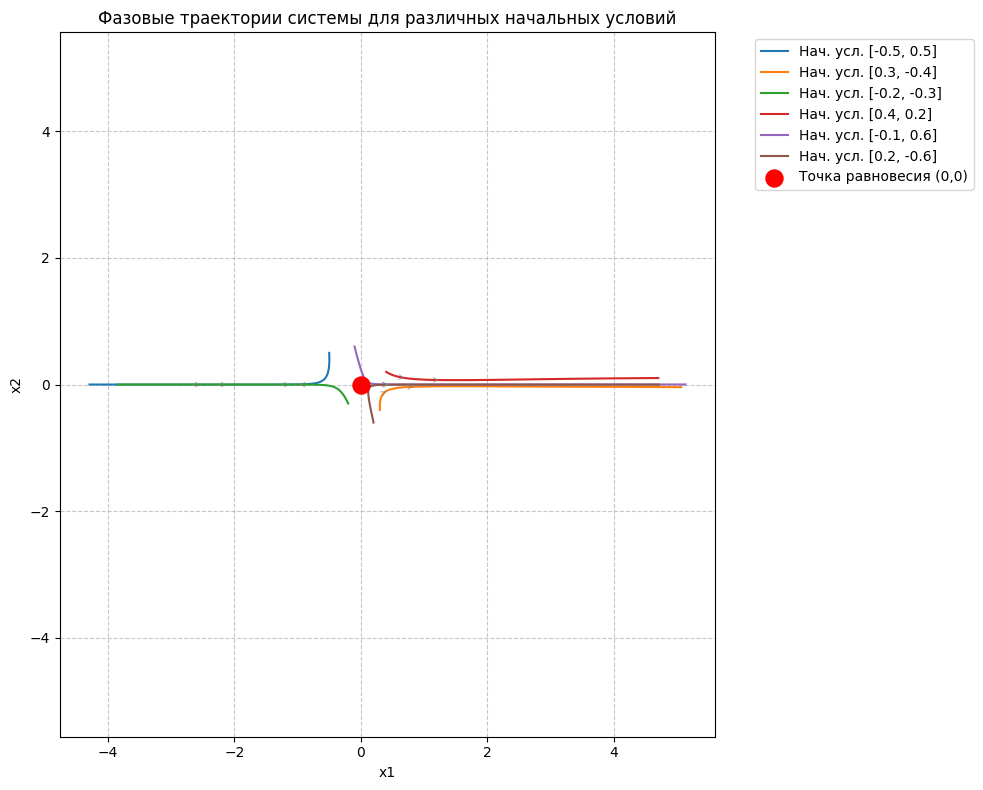

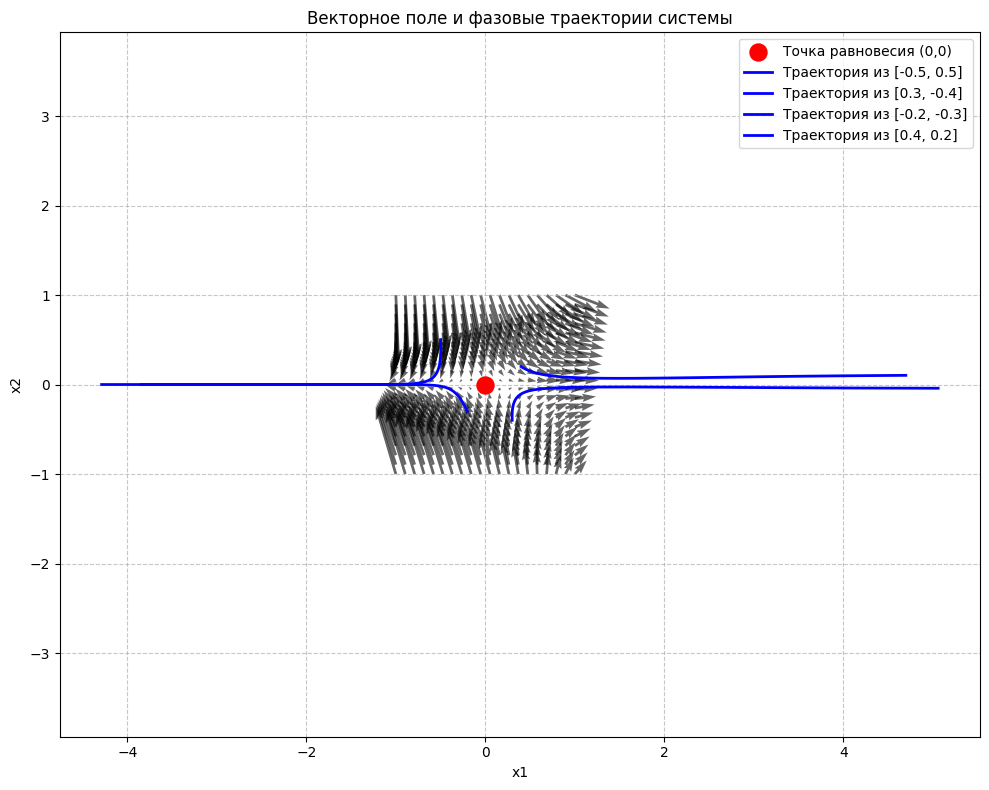

In [1]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import warnings
warnings.filterwarnings("ignore")

# Определение символьных переменных
x1, x2 = sp.symbols('x1 x2')

# Задание системы дифференциальных уравнений
# dx1/dt = f1(x1, x2) = exp(x1) + sin(x2) - 1
# dx2/dt = f2(x1, x2) = 2*x1*x2 - 3*x2
f1 = sp.exp(x1) + sp.sin(x2) - 1
f2 = 2*x1*x2 - 3*x2

F = sp.Matrix([f1, f2])
X = sp.Matrix([x1, x2])

# Вычисление якобиана системы
# Якобиан - это матрица частных производных векторного поля по переменным
J = F.jacobian(X)

print('Якобиан системы:')
print(J)

# Подстановка значений в точке равновесия (0, 0)
# Точка равновесия - это точка, где правая часть системы обращается в ноль
J0 = J.subs({x1:0, x2:0}) # точка равновесия (0, 0)

print("\nЯкобиан в точке (0,0):")
print(J0)

# Преобразование в численный массив NumPy для вычисления собственных значений
A = np.array(J0).astype(float)
eigenvalues = np.linalg.eigvals(A)

print("\nСобственные значения якобиана в точке (0,0):")
print(eigenvalues)

# Теория устойчивости по Ляпунову:
# Для анализа устойчивости точки равновесия линеаризованной системы:
# - Если все собственные значения имеют отрицательную вещественную часть -> асимптотически устойчиво
# - Если хотя бы одно собственное значение имеет положительную вещественную часть -> неустойчиво
# - Если есть собственные значения с нулевой вещественной частью -> требуется дополнительный анализ

if all(np.real(eig) < 0 for eig in eigenvalues):
    print("\nТочка (0,0) является асимптотически устойчивой.")
elif any(np.real(eig) > 0 for eig in eigenvalues):
    print("\nТочка (0,0) является неустойчивой.")
else:
    print("\nАнализ устойчивости требует дополнительного исследования.")

# Определение функции системы для численного интегрирования
def system(t, x):
    """
    Функция, определяющая систему обыкновенных дифференциальных уравнений:
    dx1/dt = exp(x1) + sin(x2) - 1
    dx2/dt = 2*x1*x2 - 3*x2
    """
    x1, x2 = x
    dx1 = np.exp(x1) + np.sin(x2) - 1
    dx2 = 2*x1*x2 - 3*x2
    return [dx1, dx2]

# Параметры численного интегрирования
t_span = [0, 5]  # Интервал времени
t = np.linspace(0, 5, 500)  # Временные точки для оценки решения

# Начальные условия
x0 = [-0.5, 0.5]

# Решение системы дифференциальных уравнений
sol = solve_ivp(system, t_span, x0, t_eval=t)

# Визуализация фазовой траектории
plt.figure(figsize=(8, 6))
plt.plot(sol.y[0], sol.y[1], label=f'Траектория с начальными условиями {x0}', linewidth=2)
plt.scatter(0, 0, color='red', s=100, label='Точка равновесия (0,0)', zorder=5)

# Добавление стрелок для указания направления течения времени
if len(sol.y[0]) > 1:
    arrow_indices = np.linspace(0, len(sol.y[0])-1, 6, dtype=int)[1:-1]
    for i in arrow_indices:
        if i+1 < len(sol.y[0]):
            plt.annotate('', xy=(sol.y[0][i+1], sol.y[1][i+1]),
                        xytext=(sol.y[0][i], sol.y[1][i]),
                        arrowprops=dict(arrowstyle='->', color='blue', lw=1),
                        size=10)

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Фазовая траектория системы\n$\\dot{x_1} = e^{x_1} + \\sin(x_2) - 1$, $\\dot{x_2} = 2x_1x_2 - 3x_2$")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.axis('equal')
plt.tight_layout()
plt.show()

# Дополнительная визуализация: построение нескольких траекторий для разных начальных условий
plt.figure(figsize=(10, 8))

initial_conditions = [
    [-0.5, 0.5],
    [0.3, -0.4],
    [-0.2, -0.3],
    [0.4, 0.2],
    [-0.1, 0.6],
    [0.2, -0.6]
]

for idx, x0 in enumerate(initial_conditions):
    sol_temp = solve_ivp(system, t_span, x0, t_eval=t)
    plt.plot(sol_temp.y[0], sol_temp.y[1], label=f'Нач. усл. {x0}', linewidth=1.5)

    # Добавление стрелок для каждой траектории
    if len(sol_temp.y[0]) > 1:
        arrow_indices = np.linspace(0, len(sol_temp.y[0])-1, 4, dtype=int)[1:-1]
        for i in arrow_indices:
            if i+1 < len(sol_temp.y[0]):
                plt.annotate('', xy=(sol_temp.y[0][i+1], sol_temp.y[1][i+1]),
                            xytext=(sol_temp.y[0][i], sol_temp.y[1][i]),
                            arrowprops=dict(arrowstyle='->', color='gray', lw=0.8, alpha=0.6),
                            size=8)

plt.scatter(0, 0, color='red', s=150, label='Точка равновесия (0,0)', zorder=10)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Фазовые траектории системы для различных начальных условий")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.axis('equal')
plt.tight_layout()
plt.show()

# Визуализация векторного поля
x1_range = np.linspace(-1, 1, 20)
x2_range = np.linspace(-1, 1, 20)
X1, X2 = np.meshgrid(x1_range, x2_range)

U = np.exp(X1) + np.sin(X2) - 1  # dx1/dt
V = 2*X1*X2 - 3*X2               # dx2/dt

plt.figure(figsize=(10, 8))
plt.quiver(X1, X2, U, V, alpha=0.6)
plt.scatter(0, 0, color='red', s=150, label='Точка равновесия (0,0)', zorder=5)

# Построение траекторий поверх векторного поля
for idx, x0 in enumerate(initial_conditions[:4]):  # Используем только первые 4 для наглядности
    sol_temp = solve_ivp(system, t_span, x0, t_eval=t)
    plt.plot(sol_temp.y[0], sol_temp.y[1], 'b-', linewidth=2, label=f'Траектория из {x0}')

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Векторное поле и фазовые траектории системы")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.axis('equal')
plt.tight_layout()
plt.show()

# Теория показателей Ляпунова (Lyapunov exponents)

**Показатели Ляпунова** - это важные характеристики динамических систем, которые количественно описывают скорость разбегания близких траекторий во времени. Они дают меру чувствительности системы к начальным условиям и являются ключевыми индикаторами хаотического поведения.

## Определение:

Для динамической системы $\dot{x} = f(x)$, где $x \in \mathbb{R}^n$, показатель Ляпунова $\lambda$ определяется как:
$$
\lambda = \lim_{t \to \infty} \frac{1}{t} \ln \left| \frac{\delta x(t)}{\delta x(0)} \right|
$$
где $\delta x(t)$ - отклонение между двумя близкими траекториями в момент времени $t$.

Для $n$-мерной системы существует $n$ показателей Ляпунова, $\lambda_1 \geq \lambda_2 \geq \ldots \geq \lambda_n$. Эти значения характеризуют растяжение/сжатие вдоль разных направлений в фазовом пространстве.

## Интерпретация:

- $\lambda > 0$: соответствует экспоненциальному разбеганию траекторий, система чувствительна к начальным условиям (хаос).
- $\lambda = 0$: нейтральное направление, траектории не расходятся и не сходятся экспоненциально.
- $\lambda < 0$: экспоненциальное сближение траекторий, направление устойчиво.

## Практическое значение:

- **Один положительный показатель** в непрерывной системе часто указывает на хаотическое поведение.
- **Все отрицательные** - система стремится к устойчивой точке или предельному циклу.
- **Наличие нуля** может указывать на консервативную систему или наличие инвариантного многообразия.

Для системы:
$$
\begin{cases}
\dot{x_1} = e^{x_1} + \sin(x_2) - 1 \\
\dot{x_2} = 2x_1x_2 - 3x_2
\end{cases}
$$

Мы будем использовать численный метод, основанный на линеаризации системы и отслеживании эволюции малых возмущений. Это делается через решение системы уравнений в вариациях:

$$
\frac{d}{dt}\delta x = J(x(t)) \cdot \delta x
$$

где $J(x(t))$ - якобиан в точке $x(t)$, который мы уже вычислили:
$$
J = \begin{pmatrix}
e^{x_1} & \cos(x_2) \\
2x_2 & 2x_1 - 3
\end{pmatrix}
$$

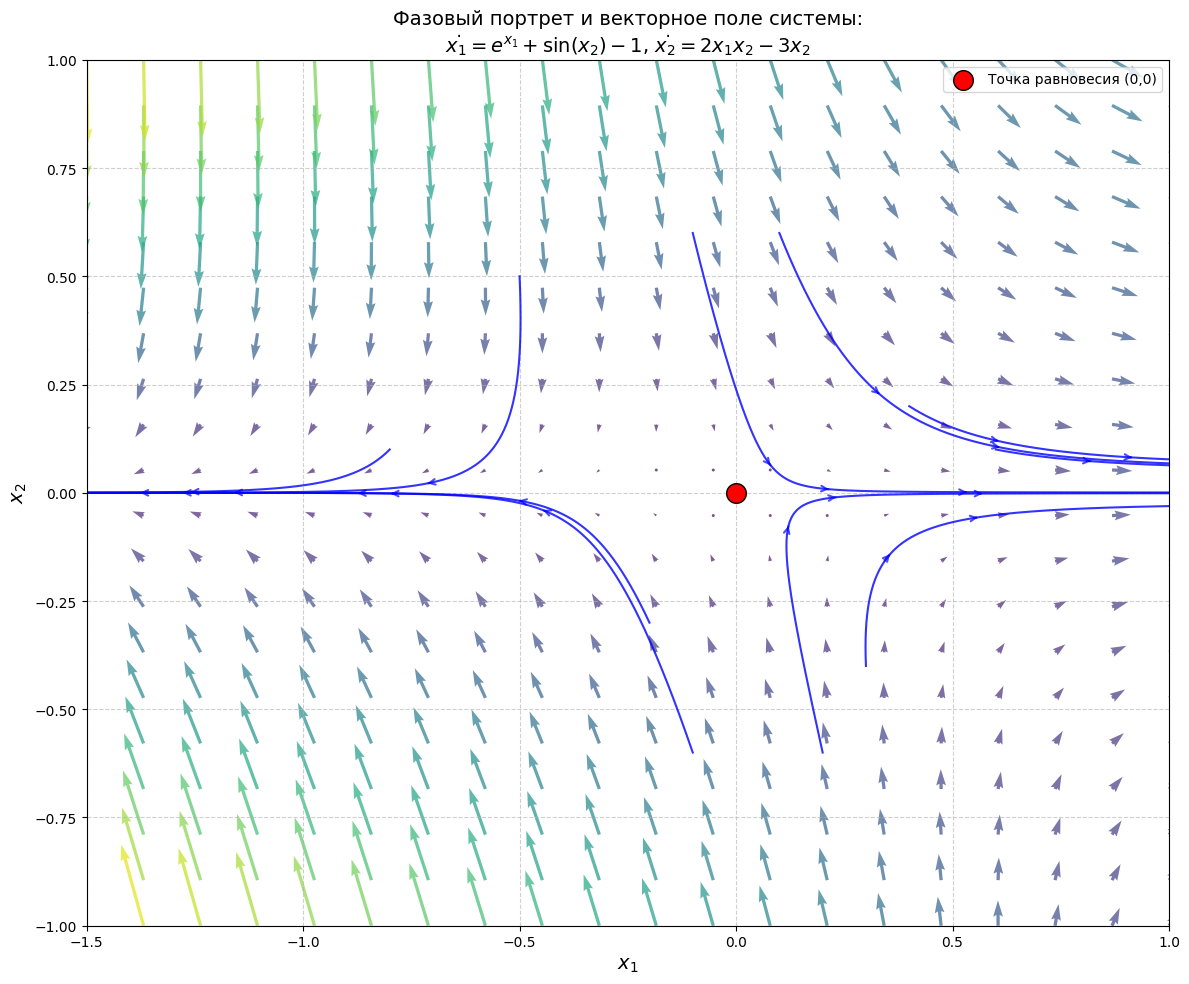

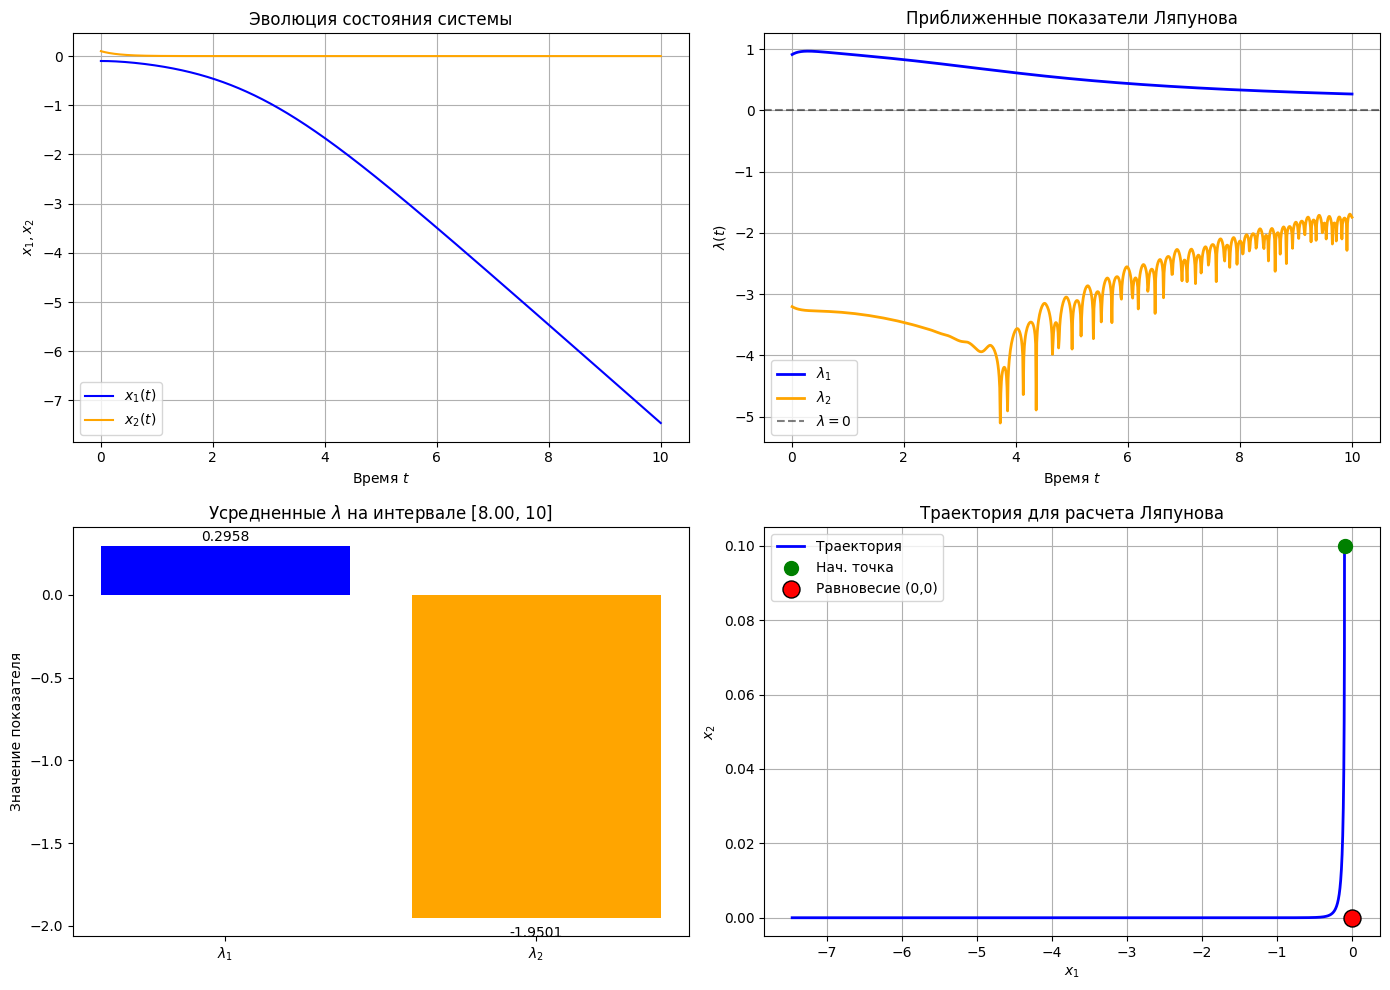

Усредненные показатели Ляпунова на последнем участке:
λ₁ ≈ 0.295776
λ₂ ≈ -1.950084

Система проявляет чувствительность к начальным условиям.
- Положительный λ₁ указывает на экспоненциальное разбегание по одному направлению.


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

def system(t, state):
    """Основная система уравнений."""
    x1, x2 = state
    dx1 = np.exp(x1) + np.sin(x2) - 1
    dx2 = 2*x1*x2 - 3*x2
    return [dx1, dx2]

def jacobian_matrix(state):
    """Вычисление якобиана в заданной точке."""
    x1, x2 = state
    J = np.array([
        [np.exp(x1), np.cos(x2)],
        [2*x2, 2*x1 - 3]
    ])
    return J

def system_with_variations(t, y_augmented):
    """
    Система уравнений + уравнения в вариациях.
    y_augmented = [x1, x2, delta1_x1, delta1_x2, delta2_x1, delta2_x2]
    """
    x = y_augmented[:2]  # [x1, x2]
    Delta = y_augmented[2:].reshape(2, 2)  # Матрица вариаций (2x2)

    # Основная динамика
    dx = system(t, x)

    # Матрица Якоби в текущей точке
    J = jacobian_matrix(x)

    # Уравнения в вариациях: d(Delta)/dt = J * Delta
    dDelta_dt = J @ Delta

    return np.concatenate([dx, dDelta_dt.flatten()])

# === ПОСТРОЕНИЕ ФАЗОВОГО ПОРТРЕТА И ВЕКТОРНОГО ПОЛЯ ===

# Определяем сетку для векторного поля
x1_range = np.linspace(-1.5, 1.0, 20)
x2_range = np.linspace(-1.0, 1.0, 20)
X1, X2 = np.meshgrid(x1_range, x2_range)

# Вычисляем векторное поле
U = np.exp(X1) + np.sin(X2) - 1  # dx1/dt
V = 2*X1*X2 - 3*X2               # dx2/dt

fig, ax = plt.subplots(figsize=(12, 10))

# Отображаем векторное поле
M = np.hypot(U, V)
ax.quiver(X1, X2, U, V, M, alpha=0.7, cmap='viridis')

# Определяем начальные условия для нескольких траекторий
initial_conditions = [
    [-0.5, 0.5],   # сверху слева
    [0.3, -0.4],   # снизу справа
    [-0.2, -0.3],  # снизу слева
    [0.4, 0.2],    # сверху справа
    [-0.1, 0.6],   # ближе к центру сверху
    [0.2, -0.6],   # ближе к центру снизу
    [-0.8, 0.1],   # левее
    [0.6, 0.1],    # правее
    [-0.1, -0.6],  # снизу от центра
    [0.1, 0.6]     # сверху от центра
]

# Интегрируем систему для каждого начального условия
t_span = [0, 3]
t_eval = np.linspace(0, 3, 500)

for idx, x0 in enumerate(initial_conditions):
    sol = solve_ivp(system, t_span, x0, t_eval=t_eval, max_step=0.01)
    ax.plot(sol.y[0], sol.y[1], 'b-', linewidth=1.5, alpha=0.8)

    # Добавляем стрелки для направления течения
    n_arrows = 3
    step = len(sol.y[0]) // (n_arrows + 1)
    for k in range(1, n_arrows + 1):
        i = k * step
        if i < len(sol.y[0]) - 1:
            ax.annotate('', xy=(sol.y[0][i+1], sol.y[1][i+1]),
                       xytext=(sol.y[0][i], sol.y[1][i]),
                       arrowprops=dict(arrowstyle='->', color='blue', lw=1.5, alpha=0.7))

# Отмечаем точку равновесия
ax.scatter(0, 0, color='red', s=200, label='Точка равновесия (0,0)', zorder=5, edgecolors='black')

ax.set_xlabel('$x_1$', fontsize=14)
ax.set_ylabel('$x_2$', fontsize=14)
ax.set_title('Фазовый портрет и векторное поле системы:\n'
             '$\\dot{x_1} = e^{x_1} + \\sin(x_2) - 1$, $\\dot{x_2} = 2x_1x_2 - 3x_2$', fontsize=14)
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(loc='upper right')
ax.set_xlim(-1.5, 1.0)
ax.set_ylim(-1.0, 1.0)
ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()

# === РАСЧЕТ ПОКАЗАТЕЛЕЙ ЛЯПУНОВА ===

# Начальные условия для расчета показателей Ляпунова
x0_lyap = [-0.1, 0.1]
Delta0 = np.eye(2)
y0_aug = np.concatenate([x0_lyap, Delta0.flatten()])

t_max = 10
t_eval_full = np.linspace(0, t_max, 1000)

solution = solve_ivp(
    system_with_variations,
    [0, t_max],
    y0_aug,
    t_eval=t_eval_full,
    method='RK45'
)

# Извлечение решений
x_solution = solution.y[:2].T
Delta_solution = solution.y[2:].T

lyapunov_exponents = []
for i in range(len(t_eval_full)):
    Delta_t = Delta_solution[i].reshape(2, 2)
    # QR-разложение для ортогонализации
    Q, R = np.linalg.qr(Delta_t.T)
    Delta_solution[i] = R.T.flatten()

    # Накопление норм
    if i > 0:
        lyap_exp = np.log(np.abs(np.diag(R))) / t_eval_full[i]
        if len(lyapunov_exponents) == 0:
            lyapunov_exponents = [[lyap_exp[0]], [lyap_exp[1]]]
        else:
            lyapunov_exponents[0].append(lyap_exp[0])
            lyapunov_exponents[1].append(lyap_exp[1])

# Построение графиков
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(solution.t, x_solution[:, 0], label='$x_1(t)$', color='blue')
axes[0, 0].plot(solution.t, x_solution[:, 1], label='$x_2(t)$', color='orange')
axes[0, 0].set_title('Эволюция состояния системы')
axes[0, 0].set_xlabel('Время $t$')
axes[0, 0].set_ylabel('$x_1, x_2$')
axes[0, 0].legend()
axes[0, 0].grid(True)

axes[0, 1].plot(solution.t[1:], lyapunov_exponents[0], label='$\\lambda_1$', linewidth=2, color='blue')
axes[0, 1].plot(solution.t[1:], lyapunov_exponents[1], label='$\\lambda_2$', linewidth=2, color='orange')
axes[0, 1].axhline(y=0, color='k', linestyle='--', alpha=0.5, label='$\\lambda=0$')
axes[0, 1].set_title('Приближенные показатели Ляпунова')
axes[0, 1].set_xlabel('Время $t$')
axes[0, 1].set_ylabel('$\\lambda(t)$')
axes[0, 1].legend()
axes[0, 1].grid(True)

# Усредненные значения за последние 20% времени
last_idx = int(0.8 * len(lyapunov_exponents[0]))
avg_l1 = np.mean(lyapunov_exponents[0][last_idx:])
avg_l2 = np.mean(lyapunov_exponents[1][last_idx:])

axes[1, 0].bar(['$\\lambda_1$', '$\\lambda_2$'], [avg_l1, avg_l2], color=['blue', 'orange'])
axes[1, 0].set_title(f'Усредненные $\\lambda$ на интервале [{solution.t[last_idx]:.2f}, {t_max}]')
axes[1, 0].set_ylabel('Значение показателя')
for i, v in enumerate([avg_l1, avg_l2]):
    axes[1, 0].text(i, v + (0.01 if v >= 0 else -0.05), f'{v:.4f}', ha='center', va='bottom' if v >= 0 else 'top')

# Фазовая траектория для расчета Ляпунова
axes[1, 1].plot(x_solution[:, 0], x_solution[:, 1], 'b-', linewidth=2, label='Траектория')
axes[1, 1].scatter(x0_lyap[0], x0_lyap[1], color='green', s=100, label='Нач. точка', zorder=5)
axes[1, 1].scatter(0, 0, color='red', s=150, label='Равновесие (0,0)', zorder=5, edgecolors='black')
axes[1, 1].set_title('Траектория для расчета Ляпунова')
axes[1, 1].set_xlabel('$x_1$')
axes[1, 1].set_ylabel('$x_2$')
axes[1, 1].legend()
axes[1, 1].grid(True)
axes[1, 1].set_aspect('auto', adjustable='box')

plt.tight_layout()
plt.show()

print(f"Усредненные показатели Ляпунова на последнем участке:")
print(f"λ₁ ≈ {avg_l1:.6f}")
print(f"λ₂ ≈ {avg_l2:.6f}")

if avg_l1 > 0 or avg_l2 > 0:
    print("\nСистема проявляет чувствительность к начальным условиям.")
    if avg_l1 > 0:
        print("- Положительный λ₁ указывает на экспоненциальное разбегание по одному направлению.")
else:
    print("\nСистема не проявляет экспоненциальной нестабильности на данном временном интервале.")

Для нашей  системы:

- Мы знаем из линейного анализа, что точка $(0,0)$ неустойчива (одно собственное значение $+1$, другое $-3$).
- Показатели Ляпунова, рассчитанные численно, должны отражать эту нестабильность.
- Вблизи точки равновесия $(0,0)$, показатель Ляпунова, связанный с направлением $x_1$, вероятно, будет положительным (соответствует собственному значению $+1$), а другой - отрицательным (соответствует $-3$).
- Это подтверждает, что система ведет себя как **седловая точка**, где траектории расходятся в одном направлении и сходятся в другом.

Этот метод позволяет оценить устойчивость сложных нелинейных систем, даже когда аналитический анализ затруднен.